In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [24]:
df = pd.read_csv("indian_roads_dataset.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (20000, 24)
   accident_id        city        state   latitude  longitude        date  \
0            0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1            1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2            2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3            3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4            4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   

    time  hour day_of_week  is_weekend  ... visibility  temperature  \
0   5:00     5      Sunday           1  ...        low           32   
1   4:00     4      Sunday           1  ...       high           34   
2  13:00    13   Wednesday           0  ...        low           21   
3  11:00    11      Sunday           1  ...        low           30   
4  16:00    16    Thursday           0  ...       high           24   

   traffic_density        cause accident_severity  vehicles_involved  \
0             high 

In [25]:
print("Null values in each column:")
print(df.isnull().sum())

Null values in each column:
accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64


In [26]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (20000, 24)


In [27]:
df = df.drop(columns=['accident_id', 'date', 'time', 'latitude', 'longitude', 'city', 'state'])
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


Class distribution:
accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64


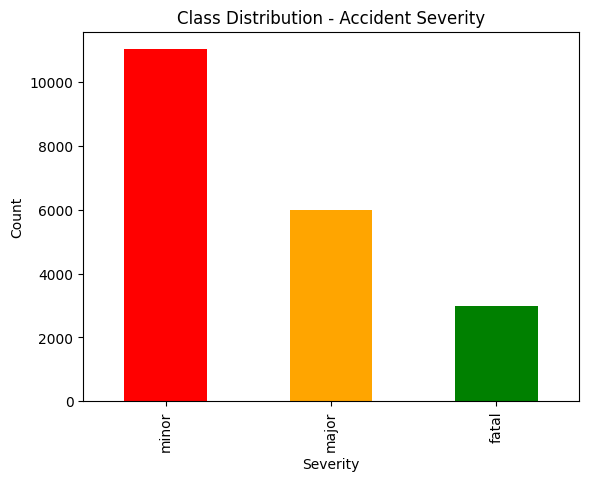

In [28]:
print("Class distribution:")
print(df['accident_severity'].value_counts())

df['accident_severity'].value_counts().plot(kind='bar', color=['red','orange','green'])
plt.title("Class Distribution - Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

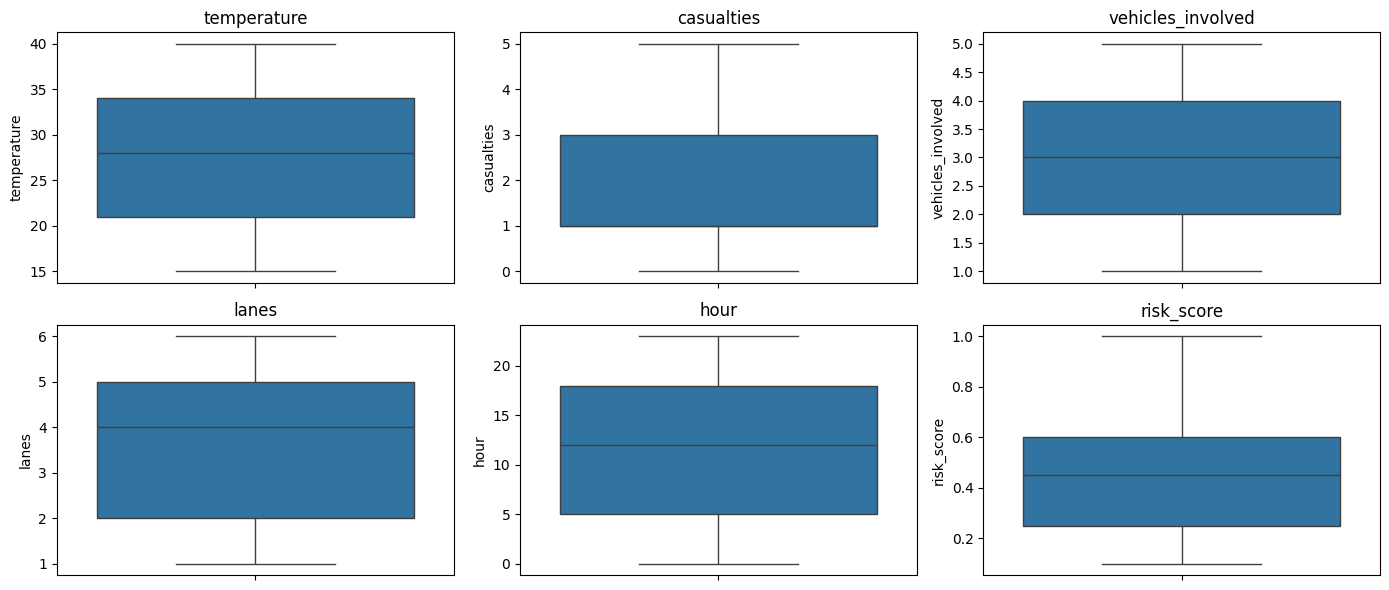

In [29]:
# Check outliers in numerical columns
numerical_cols = ['temperature', 'casualties', 'vehicles_involved', 'lanes', 'hour', 'risk_score']

plt.figure(figsize=(14, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [30]:
categorical_cols = ['day_of_week', 'road_type', 'weather', 'visibility',
                    'traffic_density', 'cause', 'festival']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode target column separately
le_target = LabelEncoder()
df['accident_severity'] = le_target.fit_transform(df['accident_severity'])

print("Classes:", le_target.classes_)   # 0=fatal, 1=major, 2=minor
print(df.head())

Classes: ['fatal' 'major' 'minor']
   hour  day_of_week  is_weekend  road_type  lanes  traffic_signal  weather  \
0     5            3           1          0      3               1        1   
1     4            3           1          2      4               0        0   
2    13            6           0          2      3               0        1   
3    11            3           1          2      1               1        1   
4    16            4           0          0      3               1        0   

   visibility  temperature  traffic_density  cause  accident_severity  \
0           1           32                0      4                  0   
1           0           34                1      4                  1   
2           1           21                2      4                  2   
3           1           30                0      0                  2   
4           0           24                1      0                  2   

   vehicles_involved  casualties  is_peak_hour  fes

In [31]:
X = df.drop(columns=['accident_severity'])
y = df['accident_severity']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (20000, 16)
y distribution:
 accident_severity
2    11025
1     5988
0     2987
Name: count, dtype: int64


In [32]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {2: 11025, 1: 5988, 0: 2987}
After SMOTE: {0: 11025, 1: 11025, 2: 11025}


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (26460, 16)
Testing size: (6615, 16)


In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multinomial Logistic Regression Accuracy: 0.6468631897203326

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      2200
           1       0.56      0.51      0.54      2196
           2       0.54      0.50      0.52      2219

    accuracy                           0.65      6615
   macro avg       0.63      0.65      0.64      6615
weighted avg       0.63      0.65      0.64      6615



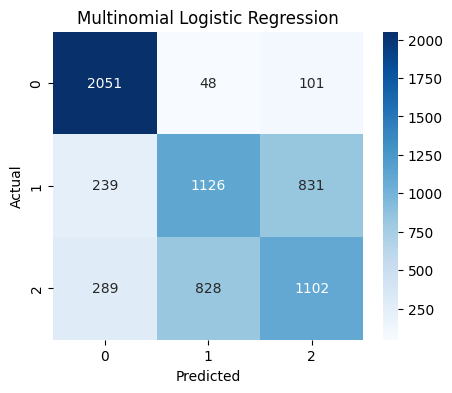

In [35]:
# Multinomial Logistic Regression

log_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Accuracy
print("Multinomial Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Multinomial Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()